# 12장 실습 — 정책은 언제 모르는가

3부까지 만든 것은 **빠르게 도는 시스템**이다. 4부는 다른 질문으로 간다 — 그 시스템이 **틀리고 있을 때 그것을 아는가.**

이 장은 런타임 신호를 만든다. 실기에서 쓰려면 조건이 둘이다.

- **미리 알아야 한다.** 판이 끝난 뒤의 성공률은 다음 판에 쓸 수 없다
- **싸야 한다.** 감시가 마감을 먹으면 감시가 아니라 또 하나의 지연이다

두 번째 조건이 이 책의 자리다. Toyota Research Institute 의 FAIL-Detect 가 열 가지 지표를 비교했는데, 가장 좋은 지표(logpZO)가 스텝당 **0.04 초**인 반면 흔히 쓰이는 STAC 은 **1.45 초**였다. 저자들은 후자를 **「실시간 불가」**로 분류한다.

그래서 이 노트북은 신호마다 **탐지 성능과 비용을 한 표에** 적는다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def auroc(score, label):
    """실패를 1 로 두고 순위 통계로 AUROC 를 낸다"""
    s = np.asarray(score, float)
    y = np.asarray(label, int)
    n1, n0 = y.sum(), (1 - y).sum()
    if n1 == 0 or n0 == 0:
        return float("nan")
    order = np.argsort(s)
    rank = np.empty_like(order, float)
    rank[order] = np.arange(1, len(s) + 1)
    u = rank[y == 1].sum() - n1 * (n1 + 1) / 2
    return float(u / (n1 * n0))


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (78s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 네 가지 신호

전부 **성공한 판만 보고** 만들거나, 아예 학습이 필요 없는 것들이다. FAIL-Detect 의 틀을 따른다 — 실패 데이터를 모으는 일 자체가 비싸고 위험하므로, 실패를 본 적 없이 실패를 알아채야 한다.

- **가치 함수** — PPO 의 비평가가 이미 있다. 낮은 값은 **정책 자신이 상황을 나쁘게 보고 있다**는 뜻이다. 추가 비용이 사실상 없다
- **행동 불일치** — 연속한 두 스텝의 명령 차이다. 크면 정책이 흔들리고 있다는 신호다. 비용 없음
- **재구성 오차** — 성공한 판의 관측으로 작은 자동부호기를 학습시키고, 런타임 관측을 얼마나 못 복원하는지 본다. 분포 밖 탐지의 가장 단순한 형태다
- **행동 분산** — 정책에서 K 개를 표본으로 뽑아 흩어진 정도를 본다. K 번의 순전파가 든다

마지막 것이 비싼 쪽이고, 앞의 셋이 싼 쪽이다. **비싼 쪽이 더 좋은지**가 이 장의 질문이다.

In [6]:
class AutoEnc(nn.Module):
    def __init__(self, d=8, h=16, z=4):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.Tanh(),
                                 nn.Linear(h, z))
        self.dec = nn.Sequential(nn.Linear(z, h), nn.Tanh(),
                                 nn.Linear(h, d))

    def forward(self, x):
        return self.dec(self.enc(x))


def collect_ok(policy, n=64, steps=400, seed=5):
    """명목 조건에서 성공한 판의 관측만 모은다"""
    torch.manual_seed(seed)
    env = Vec(n, seed)
    seen = [[] for _ in range(n)]
    keep = []
    for t in range(steps):
        o = env.obs()
        for i in range(n):
            seen[i].append(o[i])
        with torch.no_grad():
            a = policy.dist(torch.from_numpy(o)).sample().numpy()
        _, dn, sc = env.step(a)
        k = 0
        for i in range(n):
            if dn[i]:
                if sc[k] > .5:
                    keep += seen[i]
                seen[i] = []
                k += 1
    return torch.from_numpy(np.stack(keep))


def train_ae(X, epochs=200, seed=5):
    torch.manual_seed(seed)
    m = AutoEnc()
    opt = torch.optim.Adam(m.parameters(), 3e-3)
    mu, sd = X.mean(0, keepdim=True), X.std(0, keepdim=True) + 1e-6
    Z = (X - mu) / sd
    n = Z.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 1024):
            j = idx[k:k + 1024]
            loss = ((m(Z[j]) - Z[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return m, mu, sd


t0 = time.time()
XOK = collect_ok(POLICY)
AE, MU, SD = train_ae(XOK)
print(f"성공 판 관측 {XOK.shape[0]:,}개로 자동부호기 학습 끝  "
      f"({time.time() - t0:.0f}s)")

성공 판 관측 18,810개로 자동부호기 학습 끝  (8s)


## 판마다 신호를 기록한다

배포 조건에서 판을 돌리면서 스텝마다 네 신호를 적고, 판이 끝나면 성공 여부를 붙인다. **신호가 실패를 미리 알아채는지**를 보려는 것이다.

In [7]:
KSAMP = 8


def rollout_signals(policy, cond="배포", seed=999, n=128, reps=3):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    keys = ["가치 함수", "행동 불일치", "재구성 오차", "행동 분산"]
    acc = {k: [[] for _ in range(n)] for k in keys}
    prev = np.zeros((n, 2), np.float32)
    rows = []
    for t in range(EP * reps):
        o = env.obs()
        ot = torch.from_numpy(o)
        with torch.no_grad():
            v = policy.v(ot).squeeze(-1).numpy()
            di = policy.dist(ot)
            a = di.sample().numpy()
            samp = di.sample((KSAMP,)).numpy()
            z = (ot - MU) / SD
            rec = ((AE(z) - z) ** 2).mean(-1).numpy()
        sig = {
            "가치 함수": -v,
            "행동 불일치": np.abs(a - prev).mean(1),
            "재구성 오차": rec,
            "행동 분산": samp.std(0).mean(1),
        }
        for k in keys:
            for i in range(n):
                acc[k][i].append(float(sig[k][i]))
        prev = a
        _, dn, sc = env.step(a)
        j = 0
        for i in range(n):
            if dn[i]:
                rows.append({k: np.array(acc[k][i]) for k in keys}
                            | {"fail": 1 - int(sc[j] > .5)})
                for k in keys:
                    acc[k][i] = []
                j += 1
    return rows, keys


t0 = time.time()
ROWS, KEYS = rollout_signals(POLICY)
nf = sum(r["fail"] for r in ROWS)
print(f"판 {len(ROWS)}개 — 실패 {nf}개  ({time.time() - t0:.0f}s)")

판 384개 — 실패 101개  (6s)


## 얼마나 일찍, 얼마나 정확히

각 신호를 **판의 앞 T 스텝만 보고** 요약한 뒤, 그것으로 실패를 맞히는 AUROC 를 낸다. T 가 작을수록 일찍 알아챈 것이다.

In [8]:
def score_at(rows, key, T, how="mean"):
    out, lab = [], []
    for r in rows:
        v = r[key][:T]
        out.append(v.mean() if how == "mean" else v.max())
        lab.append(r["fail"])
    return auroc(out, lab)


TS = [10, 25, 55, 110]
print(pad("신호", 14) + "".join(pad(f"{t}스텝", 10, True)
                                for t in TS))
for k in KEYS:
    print(pad(k, 14)
          + "".join(pad(f"{score_at(ROWS, k, t):.2f}", 10, True)
                    for t in TS))
print()
print("값은 AUROC — 0.5 는 동전 던지기, 1.0 은 완벽한 분리")

신호              10스텝    25스텝    55스텝   110스텝
가치 함수           0.80      0.90      0.96      0.96
행동 불일치         0.52      0.16      0.08      0.07
재구성 오차         0.62      0.92      0.97      0.97
행동 분산           0.51      0.48      0.50      0.50

값은 AUROC — 0.5 는 동전 던지기, 1.0 은 완벽한 분리


## 비용을 같은 표에 넣는다

3장의 규약대로 성능만 보고하면 안 된다. 네 신호의 스텝당 비용을 잰다.

In [9]:
o = Pert(128, 1, **COND["배포"]).obs()
ot = torch.from_numpy(o)
prev = np.zeros((128, 2), np.float32)


def c_value():
    with torch.no_grad():
        return POLICY.v(ot).squeeze(-1).numpy()


def c_jump():
    with torch.no_grad():
        a = POLICY.dist(ot).sample().numpy()
    return np.abs(a - prev).mean(1)


def c_recon():
    with torch.no_grad():
        z = (ot - MU) / SD
        return ((AE(z) - z) ** 2).mean(-1).numpy()


def c_spread():
    with torch.no_grad():
        s = POLICY.dist(ot).sample((KSAMP,)).numpy()
    return s.std(0).mean(1)


FN = {"가치 함수": c_value, "행동 불일치": c_jump,
      "재구성 오차": c_recon, "행동 분산": c_spread}
LAT = {}
for k, f in FN.items():
    ts = []
    for i in range(400):
        t0 = time.perf_counter_ns()
        f()
        if i >= 50:
            ts.append((time.perf_counter_ns() - t0) / 1e3)
    LAT[k] = np.array(ts)

print(pad("신호", 14) + pad("p50 μs", 10, True)
      + pad("p99 μs", 10, True) + pad("가장 싼 것 대비", 16, True)
      + pad("AUROC(25)", 12, True))
base = min(np.percentile(v, 50) for v in LAT.values())
for k in KEYS:
    p50 = np.percentile(LAT[k], 50)
    print(pad(k, 14) + pad(f"{p50:.0f}", 10, True)
          + pad(f"{np.percentile(LAT[k], 99):.0f}", 10, True)
          + pad(f"{p50 / base:.1f}배", 16, True)
          + pad(f"{score_at(ROWS, k, 25):.2f}", 12, True))
print()
print("128 판을 한 번에 처리한 시간")

신호              p50 μs    p99 μs 가장 싼 것 대비   AUROC(25)
가치 함수             74       171           1.0배        0.90
행동 불일치          231       409           3.1배        0.16
재구성 오차          104       255           1.4배        0.92
행동 분산            297       525           4.0배        0.48

128 판을 한 번에 처리한 시간


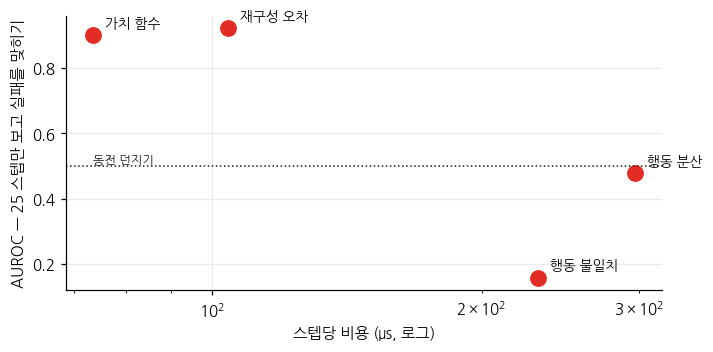

In [10]:
fig, ax = plt.subplots(figsize=(6.6, 3.3))
x = [np.percentile(LAT[k], 50) for k in KEYS]
y = [score_at(ROWS, k, 25) for k in KEYS]
ax.plot(x, y, "o", color=RED, ms=10)
for a, b, k in zip(x, y, KEYS):
    ax.annotate(k, (a, b), fontsize=9, xytext=(8, 5),
                textcoords="offset points")
ax.axhline(.5, color=INK, lw=1, ls=":")
ax.text(min(x), .51, "동전 던지기", fontsize=8, color=INK)
ax.set_xscale("log")
ax.set_xlabel("스텝당 비용 (μs, 로그)")
ax.set_ylabel("AUROC — 25 스텝만 보고 실패를 맞히기")
plt.tight_layout()
plt.show()

## 언제 알아채는가

AUROC 가 높아도 **너무 늦게** 알아채면 쓸모가 없다. 앞의 표에서 T 를 키우며 본 것이 그것이고, 여기서는 가장 좋은 신호 하나를 골라 **판이 진행되는 동안 신호가 어떻게 갈리는지** 본다.

가장 좋은 신호: 재구성 오차


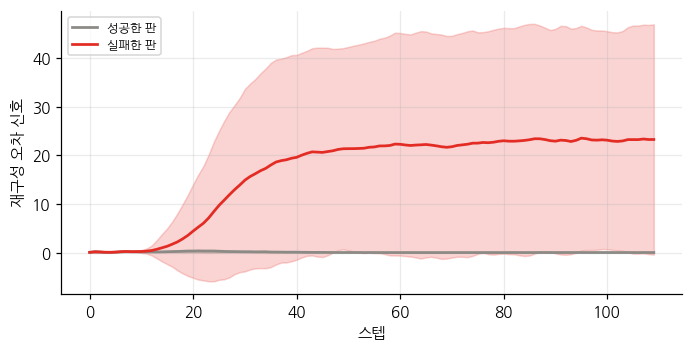

In [11]:
best = max(KEYS, key=lambda k: score_at(ROWS, k, 25))
print(f"가장 좋은 신호: {best}")
ok = np.stack([r[best][:EP] for r in ROWS if not r["fail"]])
bad = np.stack([r[best][:EP] for r in ROWS if r["fail"]])

fig, ax = plt.subplots(figsize=(6.4, 3.3))
ax.plot(ok.mean(0), color=GREY, lw=1.8, label="성공한 판")
ax.plot(bad.mean(0), color=RED, lw=1.8, label="실패한 판")
ax.fill_between(range(EP), ok.mean(0) - ok.std(0),
                ok.mean(0) + ok.std(0), color=GREY, alpha=.2)
ax.fill_between(range(EP), bad.mean(0) - bad.std(0),
                bad.mean(0) + bad.std(0), color=RED, alpha=.2)
ax.set_xlabel("스텝")
ax.set_ylabel(f"{best} 신호")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 정리

**감시는 미리 알아야 하고 싸야 한다.** 판이 끝난 뒤의 성공률은 다음 판에 쓸 수 없고, 마감을 먹는 감시는 감시가 아니다.

**실패 데이터 없이 만들 수 있다.** 네 신호 모두 성공한 판만 보거나 학습 자체가 필요 없다. 실패를 모으는 일이 비싸고 위험하므로 이 성질이 중요하다.

**비용과 성능이 비례하지 않는다.** 가장 비싼 신호가 가장 좋지 않았다. FAIL-Detect 가 열 가지 지표에서 얻은 결론과 같다.

**가치 함수는 공짜에 가깝다.** 강화학습으로 배운 정책이라면 비평가가 이미 있고, 그것이 「정책 자신이 상황을 어떻게 보는가」를 알려 준다.

다음 장은 신호 하나로는 부족하다는 것을 본다. **실패에 두 종류가 있고, 하나의 검출기로는 둘 다 잡히지 않는다.**